# Bank Loan Approval Prediction
## 1. Introduction and Setup
In this notebook, we build and compare machine learning models (Logistic Regression and Decision Tree) to predict whether a loan application will be approved or rejected. We start by importing the necessary libraries for data manipulation, visualization, preprocessing, and modeling.

In [ ]:
# Import necessary libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import plot_tree
from sklearn.metrics import precision_score, recall_score, f1_score,accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from imblearn.over_sampling import SMOTE

import joblib

## 2. Data Loading and Exploration
We load the loan approval dataset and inspect the first few rows to understand the features available, such as applicant income, loan amount, credit history, and the target variable `Loan_Status`.

In [ ]:
# Load the data

df = pd.read_csv('loan_approval.csv')
df.head()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,CreditHistory,Dependents,Education,EmploymentType,PropertyArea,MaritalStatus,Loan_Status
0,136958,50772,298430,300,1,2,Not Graduate,Self Employed,Semiurban,Single,1
1,146932,72084,205887,120,0,1,Graduate,Salaried,Semiurban,Married,1
2,118694,40149,265572,180,1,3+,Graduate,Self Employed,Rural,Single,1
3,134879,27526,144348,36,1,0,Not Graduate,Self Employed,Urban,Single,1
4,125268,68477,155736,240,1,3+,Not Graduate,Self Employed,Urban,Single,1


Next, we review the basic information and statistical summary of the dataset to check for data types, ranges, and potential anomalies.

In [ ]:
# Description and basic statistics

df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   ApplicantIncome    4000 non-null   int64 
 1   CoapplicantIncome  4000 non-null   int64 
 2   LoanAmount         4000 non-null   int64 
 3   Loan_Amount_Term   4000 non-null   int64 
 4   CreditHistory      4000 non-null   int64 
 5   Dependents         4000 non-null   object
 6   Education          4000 non-null   object
 7   EmploymentType     4000 non-null   object
 8   PropertyArea       4000 non-null   object
 9   MaritalStatus      4000 non-null   object
 10  Loan_Status        4000 non-null   int64 
dtypes: int64(6), object(5)
memory usage: 343.9+ KB


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,CreditHistory,Loan_Status
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.00000
mean,82404.366000,39191.448500,274527.928500,130.887000,0.754500,0.83675
std,39198.475219,23315.772335,128765.760647,96.149656,0.430437,0.36964
min,15126.000000,2.000000,50015.000000,12.000000,0.000000,0.00000
25%,48217.750000,19071.000000,163228.000000,60.000000,1.000000,1.00000
50%,82401.000000,38617.000000,276918.000000,120.000000,1.000000,1.00000
75%,116021.750000,59256.750000,384040.750000,240.000000,1.000000,1.00000
max,149869.000000,79980.000000,499998.000000,300.000000,1.000000,1.00000


We check for any missing values in the dataset. A clean dataset with zero null values ensures smooth preprocessing and model training.

In [ ]:
# Missing values

df.isnull().sum().sum()

np.int64(0)

Let's examine the distribution of our target variable, `Loan_Status`.

In [ ]:
# Split of target column

round(df['Loan_Status'].value_counts(normalize=True)*100,2)

,proportion
Loan_Status,
1,83.68
0,16.32


**Interpretation**: The dataset is highly imbalanced, with approximately 83.68% approved loans and 16.32% rejected loans. We will need to address this imbalance later using techniques like SMOTE before training our models.

## 3. Exploratory Data Analysis (EDA)
### Numerical Features Distribution
We visualize the distributions of our continuous numerical features using histograms.

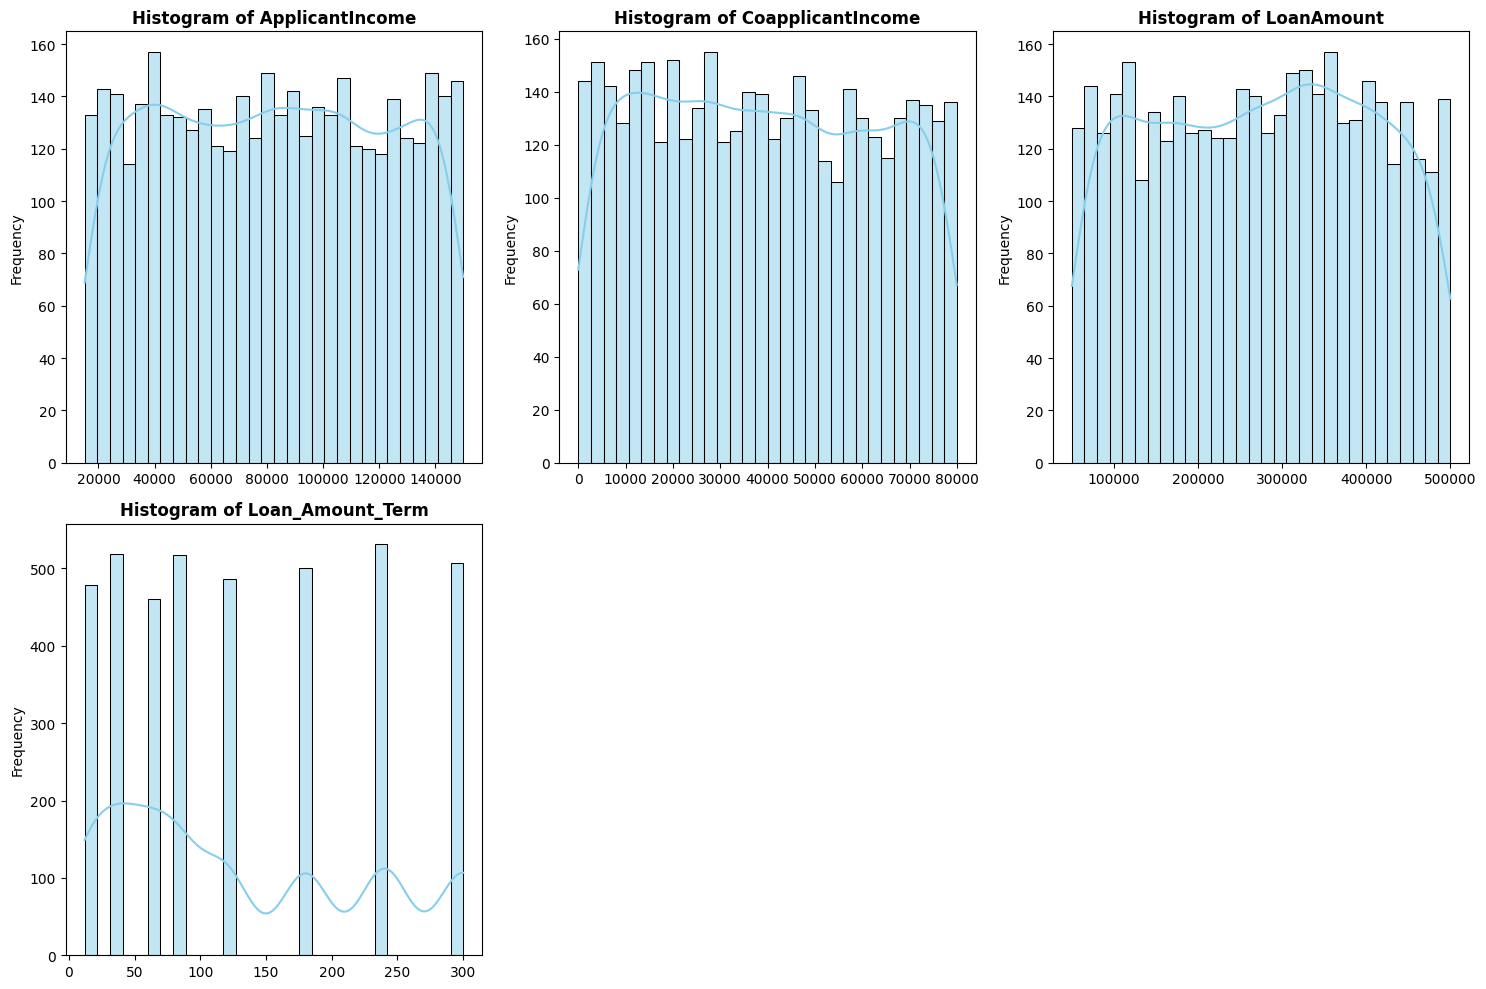

In [ ]:
# Distribution of numerical columns

numeric_cols = df[['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']]
num_plots = len(numeric_cols.columns)

rows = 2
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 5 * rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):

    sns.histplot(data=df, x=col, ax=axes[i], kde=True, color='skyblue', bins=30)
    axes[i].set_title(f'Histogram of {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frequency')

for j in range(num_plots, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**Interpretation**:
- `ApplicantIncome` and `CoapplicantIncome` are normal distributions, indicating most applicants have the uniform income range.
- `LoanAmount` is roughly normally distributed as well but also shows some right skewness.
- `Loan_Amount_Term` is peaks at around 240 months (20 years), which is standard for housing and long-term loans.

### Categorical Features Distribution
Next, we explore the categorical variables using count plots to understand the demographic and financial profile of the applicants.

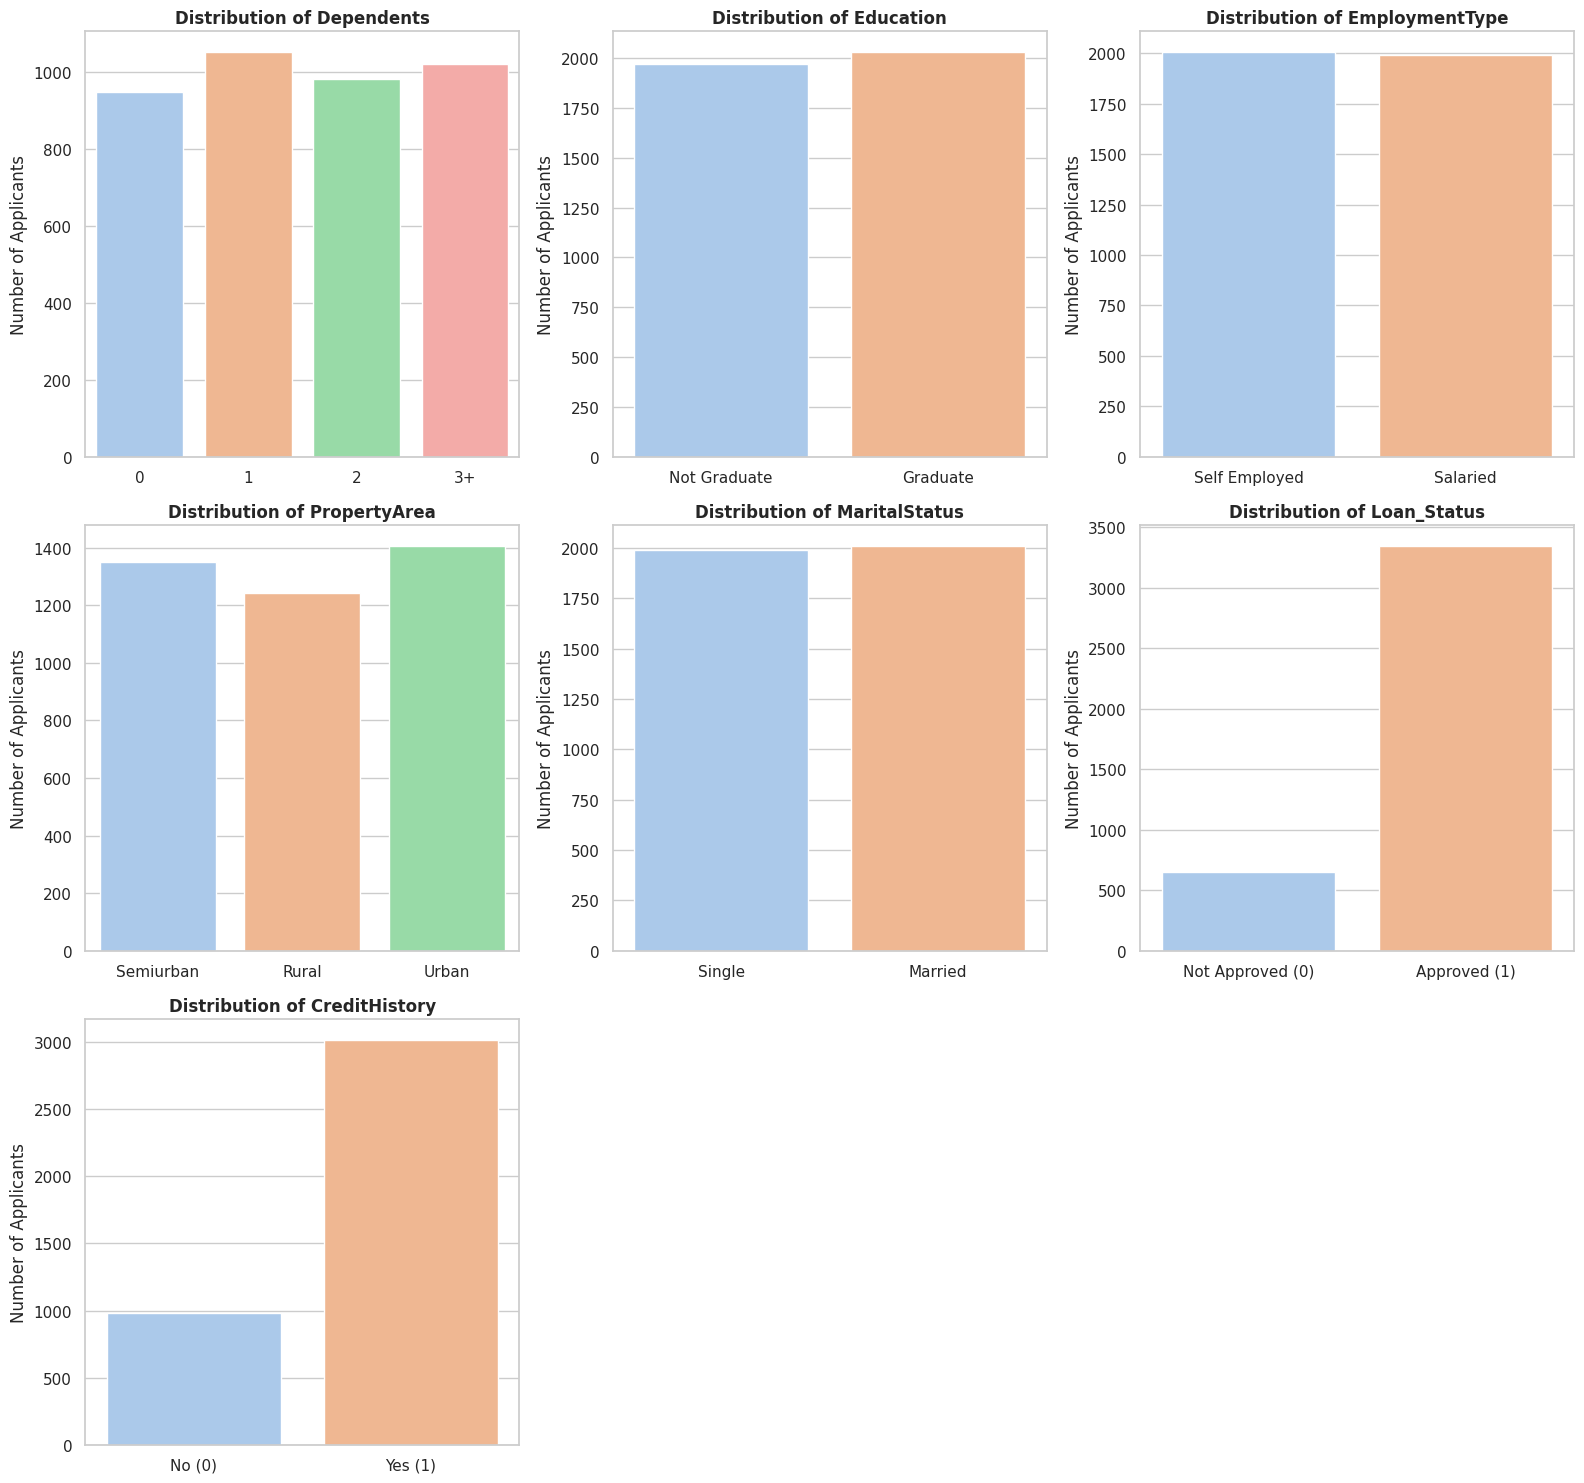

In [ ]:
# Distribution of categorical columns

sns.set_theme(style="whitegrid")

categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
categorical_cols.append('Loan_Status')
categorical_cols.append('CreditHistory')

n_cols = 3
n_rows = math.ceil(len(categorical_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):

    if col == 'Dependents':
        sns.countplot(data=df, x=col, palette='pastel', order=['0', '1', '2', '3+'], ax=axes[i])
    elif col == 'Loan_Status':
        sns.countplot(data=df, x=col, palette='pastel', ax=axes[i])
        axes[i].set_xticklabels(['Not Approved (0)', 'Approved (1)'])
    elif col == 'CreditHistory':
        sns.countplot(data=df, x=col, palette='pastel', ax=axes[i])
        axes[i].set_xticklabels(['No (0)', 'Yes (1)'])
    else:
        sns.countplot(data=df, x=col, palette='pastel', ax=axes[i])

    axes[i].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Number of Applicants')
    axes[i].set_xlabel('')

for j in range(len(categorical_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**Interpretation**:
- A large majority of applicants have a positive `CreditHistory` (Yes).
- As seen earlier; most of the applicants have go their loans approved.
- The rest of the columns are also evenly spread.
- `PropertyArea` is relatively well-distributed across Semiurban, Urban, and Rural areas.

### Feature Relationships with Loan Status
We analyze how specific features influence the likelihood of a loan being approved.

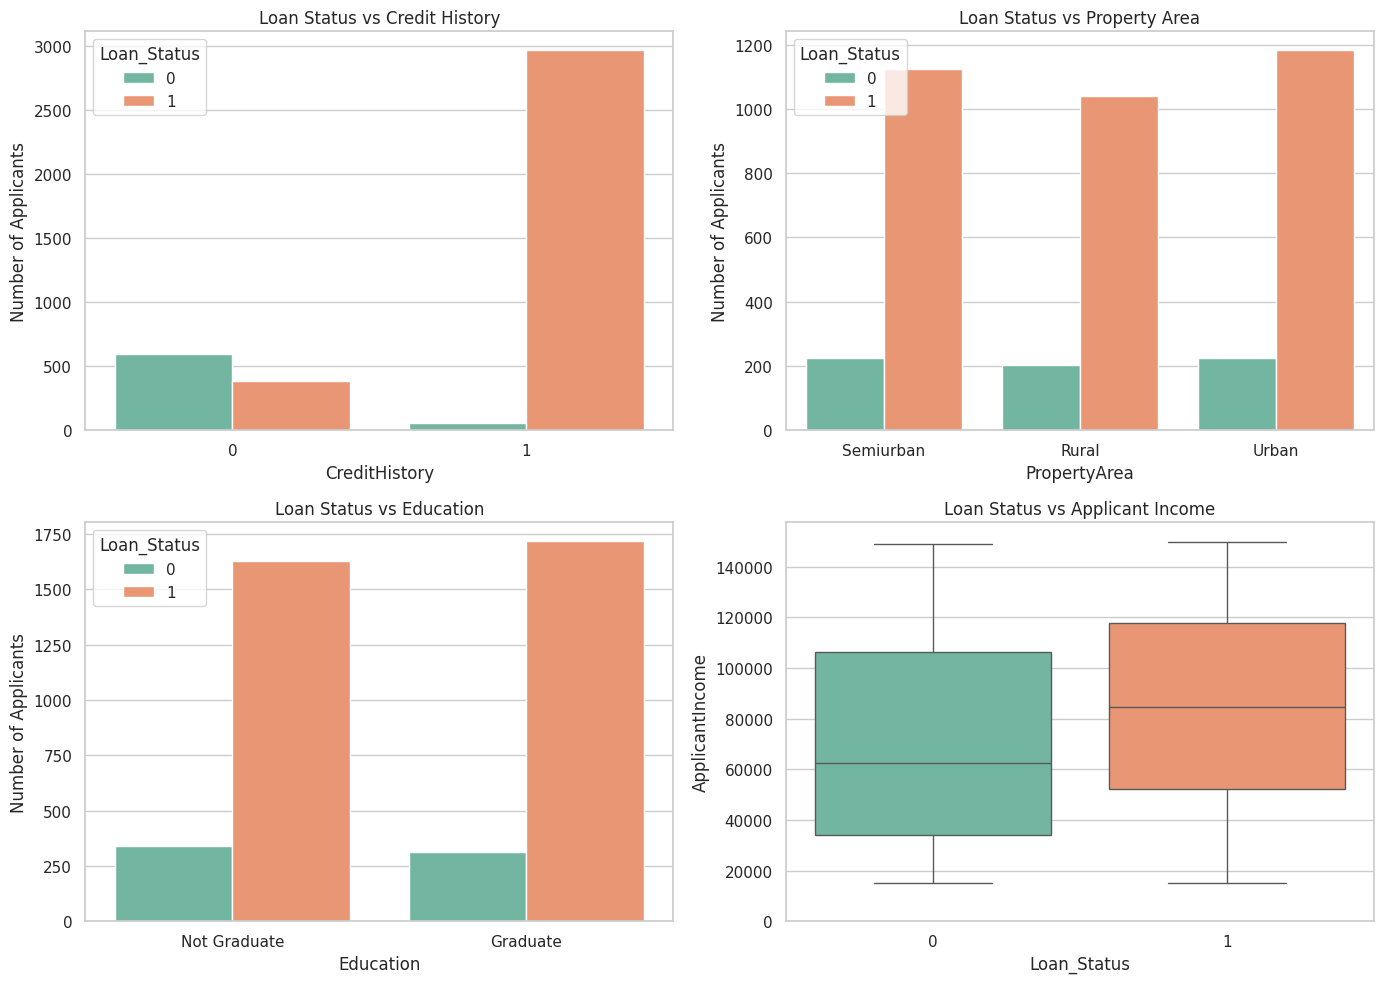

In [ ]:
# Relationships between features and target variable

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
sns.set_theme(style="whitegrid")

# 1. Loan_Status vs CreditHistory
sns.countplot(data=df, x='CreditHistory', hue='Loan_Status', ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Loan Status vs Credit History')
axes[0, 0].set_ylabel('Number of Applicants')

# 2. Loan_Status vs PropertyArea
sns.countplot(data=df, x='PropertyArea', hue='Loan_Status', ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('Loan Status vs Property Area')
axes[0, 1].set_ylabel('Number of Applicants')
axes[0,1].legend(title='Loan_Status', loc = 'upper left', labels = [0, 1])

# 3. Loan_Status vs Education
sns.countplot(data=df, x='Education', hue='Loan_Status', ax=axes[1, 0], palette='Set2')
axes[1, 0].set_title('Loan Status vs Education')
axes[1, 0].set_ylabel('Number of Applicants')

# 4. Loan_Status vs ApplicantIncome (Using Boxplots)
sns.boxplot(data=df, x='Loan_Status', y='ApplicantIncome', ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('Loan Status vs Applicant Income')
upper_limit = df['ApplicantIncome'].quantile(0.95)
axes[1, 1].set_ylim(0, upper_limit * 1.10)

plt.tight_layout()
plt.show()

**Interpretation**:
- **Credit History**: This appears to be a critical factor. Applicants with a positive credit history have a significantly higher approval rate.
- **Property Area**: Semiurban properties seem to have a slightly higher approval rate compared to rural areas.
- **Education**: Graduates have a marginally higher chance of approval.
- **Income**: The boxplot shows that while the median income for approved and rejected applications is similar, approved applications have a slightly wider range of acceptable incomes.

## 4. Data Preprocessing
### Train-Test Split
We separate our features (`X`) from the target variable (`y`) and split the data into training and testing sets. We use stratified sampling to maintain the class distribution in both splits.

In [ ]:
# Separate features and target columns

X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### Feature Engineering and Pipelines
We define our numerical, binary, and multi-class categorical columns, and create a `ColumnTransformer` to apply:
- **StandardScaler** for numerical features to normalize their range.
- **OrdinalEncoder** for binary categorical variables.
- **OneHotEncoder** for multi-class categorical variables.

In [ ]:
# Define columns and targets

numeric_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'CreditHistory']
binary_cols = ['Education', 'EmploymentType', 'MaritalStatus']
multi_cols = ['Dependents', 'PropertyArea']

# The order is ['Zero Category', 'One Category']
binary_categories = [
    ['Not Graduate', 'Graduate'],       # 0: Not Graduate, 1: Graduate
    ['Self Employed', 'Salaried'],      # 0: Self Employed, 1: Salaried
    ['Single', 'Married']]

In [ ]:
# Create the Preprocessor

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),

        ('bin_cat', OrdinalEncoder(categories=binary_categories, handle_unknown='use_encoded_value', unknown_value=-1), binary_cols),

        ('multi_cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), multi_cols)
    ]
)

### Handling Class Imbalance
We apply the transformations to our datasets and use **SMOTE (Synthetic Minority Over-sampling Technique)** on the training data to balance the minority class (rejected loans). Finally, we save the preprocessor for future deployment.

In [ ]:
# Transform the data

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_processed, y_train)

joblib.dump(preprocessor, 'loan_preprocessor.joblib')

['loan_preprocessor.joblib']

## 5. Model Training and Evaluation
### Model 1: Logistic Regression
We first train a Logistic Regression model on the balanced dataset. We extract the feature coefficients to understand which variables have the most significant impact on the model's decision.

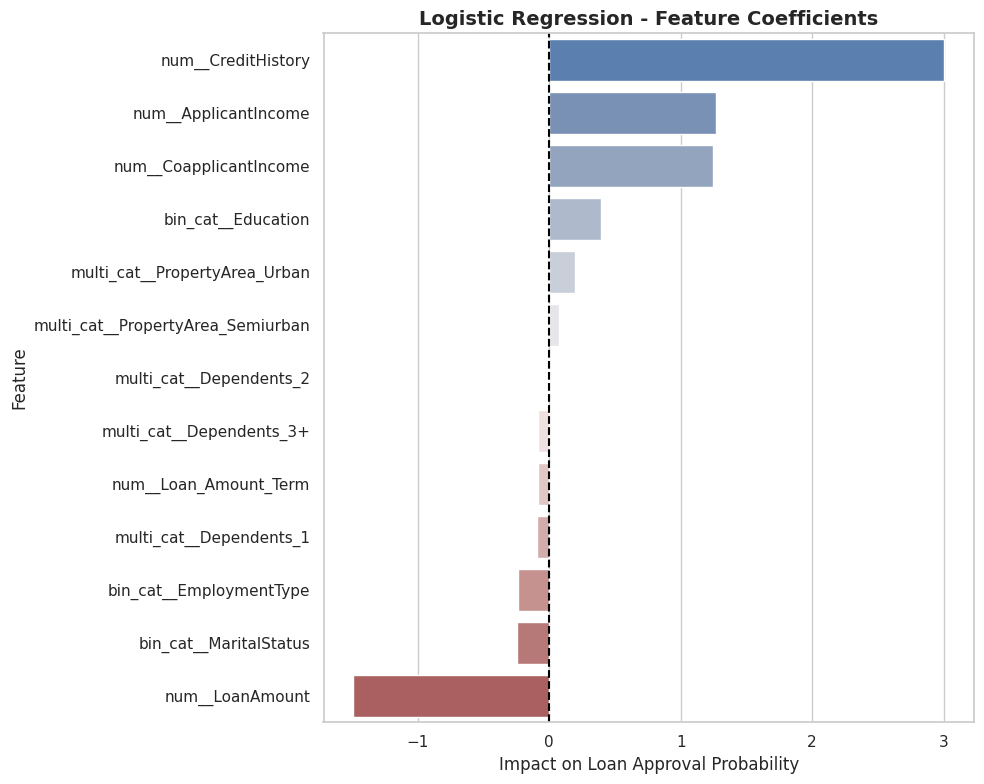


--- Mathematical Feature Weights ---
                          Feature  Coefficient
               num__CreditHistory     3.006923
             num__ApplicantIncome     1.268483
           num__CoapplicantIncome     1.242995
               bin_cat__Education     0.390966
    multi_cat__PropertyArea_Urban     0.196915
multi_cat__PropertyArea_Semiurban     0.073694
          multi_cat__Dependents_2    -0.014049
         multi_cat__Dependents_3+    -0.083774
            num__Loan_Amount_Term    -0.086126
          multi_cat__Dependents_1    -0.092999
          bin_cat__EmploymentType    -0.233890
           bin_cat__MaritalStatus    -0.241957
                  num__LoanAmount    -1.492472


In [ ]:
# Logistic Regression

log_reg = LogisticRegression(random_state=42, max_iter=1000)

log_reg.fit(X_train_balanced, y_train_balanced)

y_pred_log = log_reg.predict(X_test_processed)

y_proba_log = log_reg.predict_proba(X_test_processed)[:, 1]

feature_names = preprocessor.get_feature_names_out()

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': log_reg.coef_[0]
})

coef_df = coef_df.sort_values(by='Coefficient', ascending=False)


plt.figure(figsize=(10, 8))
sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='vlag')
plt.title('Logistic Regression - Feature Coefficients', fontsize=14, fontweight='bold')
plt.xlabel('Impact on Loan Approval Probability')
plt.ylabel('Feature')
plt.axvline(0, color='black', linestyle='--')
plt.tight_layout()
plt.show()

print("\n--- Mathematical Feature Weights ---")
print(coef_df.to_string(index=False))

### Model 2: Optimized Decision Tree
Next, we train a Decision Tree Classifier. To maximize performance and prevent overfitting, we use `GridSearchCV` to find the optimal hyperparameters.

Best Parameters Found: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 5, 'min_samples_split': 2}

--- Optimized Decision Tree Metrics (Test Data) ---
Accuracy : 0.9537
Precision: 1.0000
Recall   : 0.9447
F1 Score : 0.9716



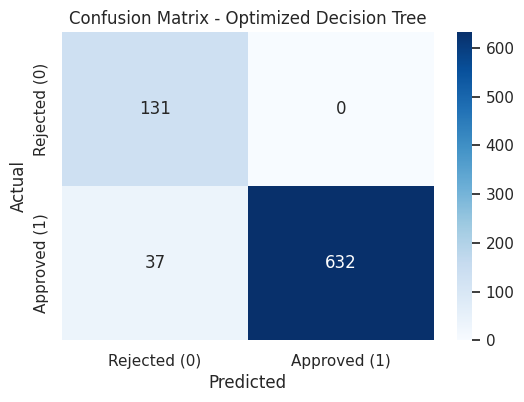

In [ ]:
# Using GridSearchCV with DecisionTree Classifier

param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10]
}

grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train_balanced, y_train_balanced)

best_tree_model = grid_search.best_estimator_

print(f"Best Parameters Found: {grid_search.best_params_}\n")

y_pred_best_tree = best_tree_model.predict(X_test_processed)

print("--- Optimized Decision Tree Metrics (Test Data) ---")
print(f"Accuracy : {accuracy_score(y_test, y_pred_best_tree):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_best_tree):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_best_tree):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_best_tree):.4f}\n")


cm = confusion_matrix(y_test, y_pred_best_tree)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Rejected (0)', 'Approved (1)'],
            yticklabels=['Rejected (0)', 'Approved (1)'])
plt.title('Confusion Matrix - Optimized Decision Tree')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## 6. Comprehensive Model Comparison
We evaluate both models using Accuracy, Precision, Recall, and F1-Score, and visualize their performance through Confusion Matrices and ROC Curves. We also plot the structure of our optimized Decision Tree.

Metric          | Logistic Regression  | Optimized Decision Tree
-----------------------------------------------------------------
Accuracy        | 0.9187               | 0.9537              
Precision       | 0.9778               | 1.0000              
Recall          | 0.9238               | 0.9447              
F1 Score        | 0.9500               | 0.9716              




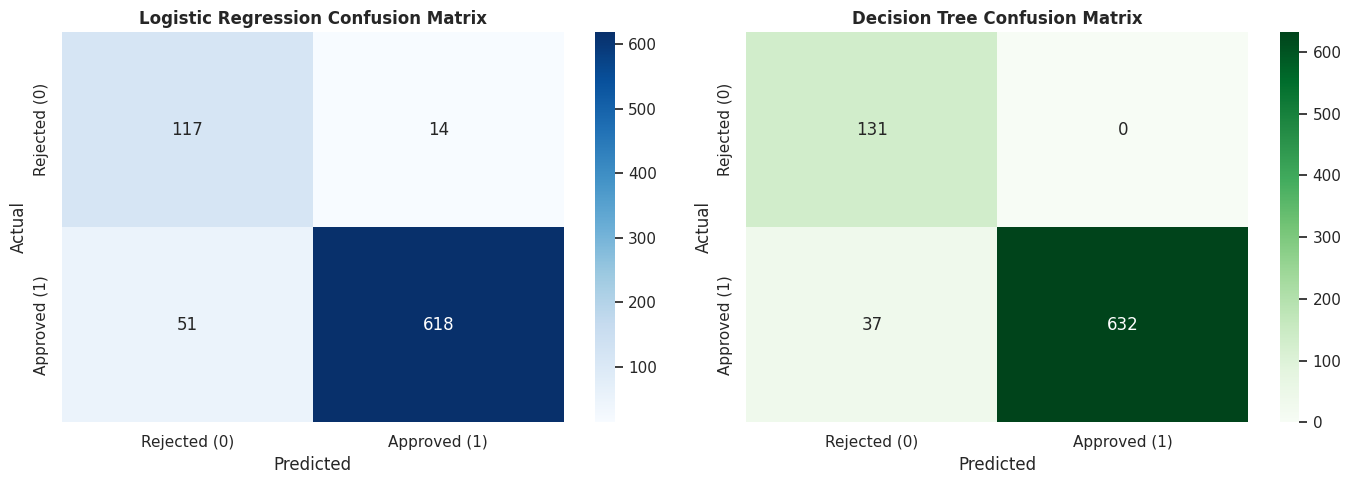

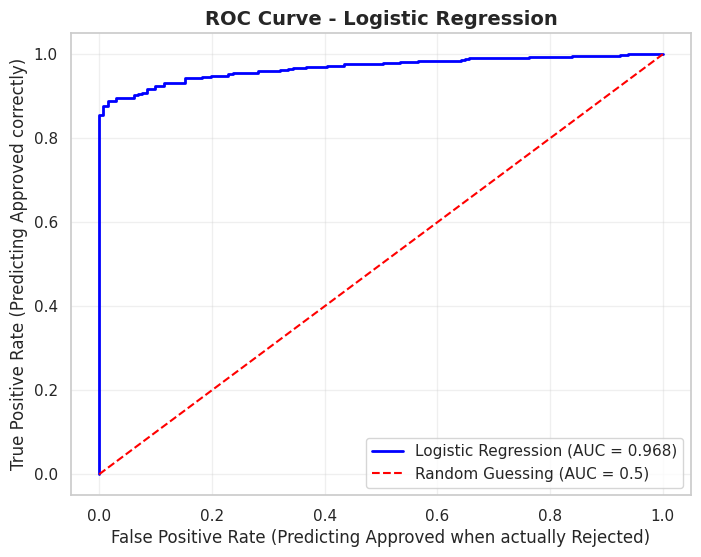

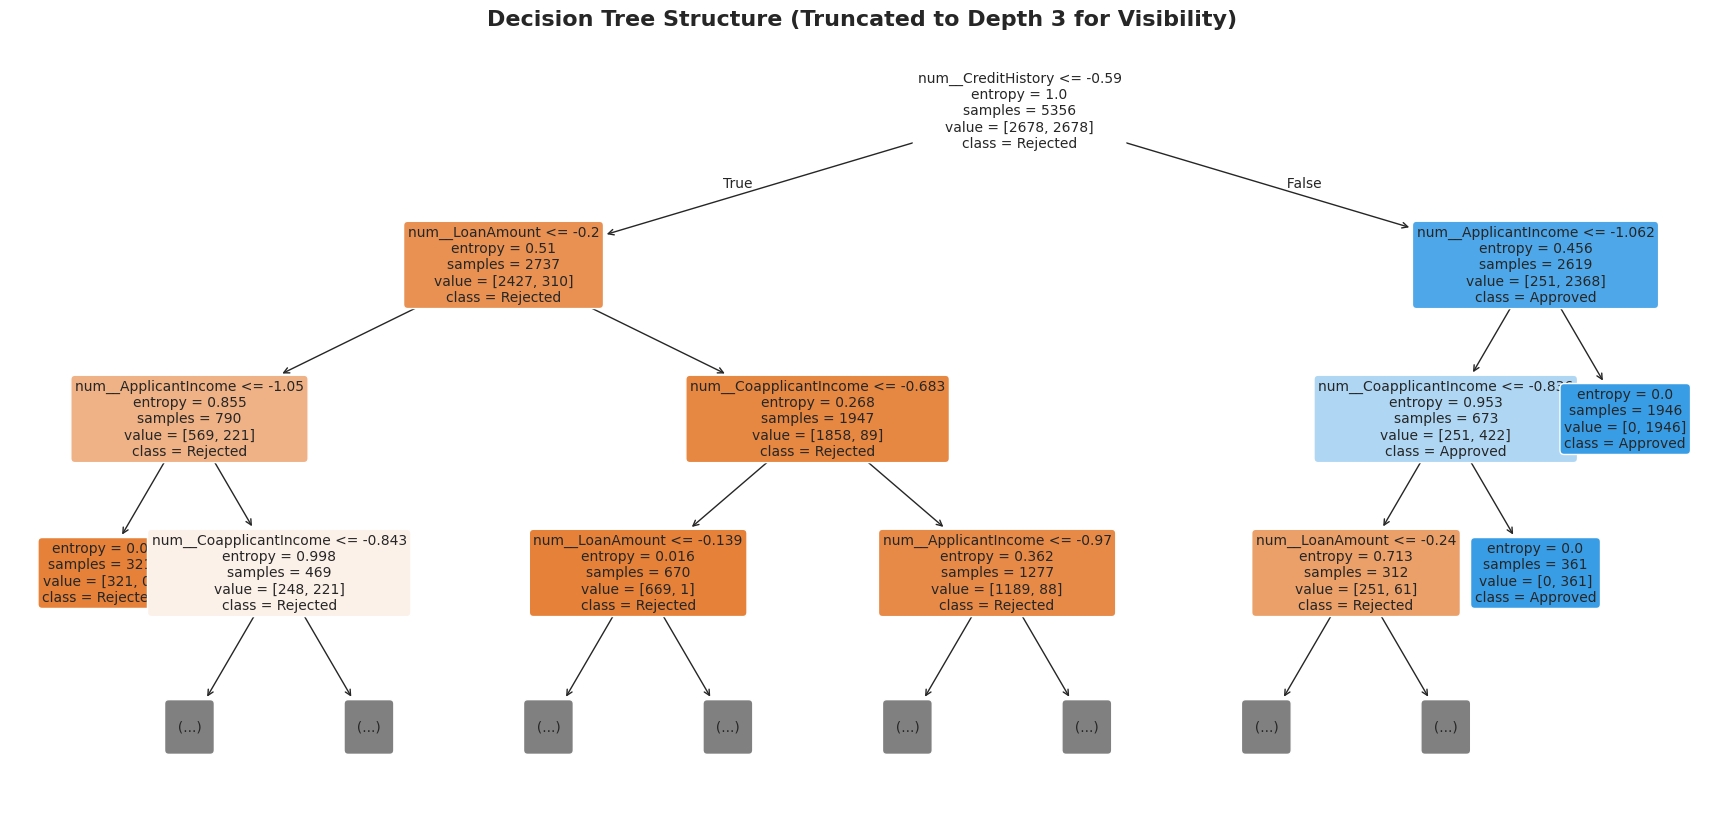

In [ ]:
# Comprehensive evaluation of both the models

def get_metrics(y_true, y_pred):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1 Score': f1_score(y_true, y_pred)
    }

log_metrics = get_metrics(y_test, y_pred_log)
tree_metrics = get_metrics(y_test, y_pred_best_tree)

print(f"{'Metric':<15} | {'Logistic Regression':<20} | {'Optimized Decision Tree':<20}")
print("-" * 65)
for metric in log_metrics.keys():
    print(f"{metric:<15} | {log_metrics[metric]:<20.4f} | {tree_metrics[metric]:<20.4f}")
print("\n")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_log = confusion_matrix(y_test, y_pred_log)
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Rejected (0)', 'Approved (1)'],
            yticklabels=['Rejected (0)', 'Approved (1)'])
axes[0].set_title('Logistic Regression Confusion Matrix', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

cm_tree = confusion_matrix(y_test, y_pred_best_tree)
sns.heatmap(cm_tree, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Rejected (0)', 'Approved (1)'],
            yticklabels=['Rejected (0)', 'Approved (1)'])
axes[1].set_title('Decision Tree Confusion Matrix', fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# Curve & AUC (Logistic Regression Specific)
# Calculates False Positive Rate and True Positive Rate
fpr, tpr, thresholds = roc_curve(y_test, y_proba_log)
auc_score = roc_auc_score(y_test, y_proba_log)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', linewidth=2, label=f'Logistic Regression (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Guessing (AUC = 0.5)')
plt.title('ROC Curve - Logistic Regression', fontsize=14, fontweight='bold')
plt.xlabel('False Positive Rate (Predicting Approved when actually Rejected)')
plt.ylabel('True Positive Rate (Predicting Approved correctly)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

# Visualize Tree Structure (Decision Tree Specific)
plt.figure(figsize=(22, 10))
plot_tree(best_tree_model, feature_names=feature_names, class_names=['Rejected', 'Approved'],
          filled=True, rounded=True, max_depth=3, fontsize=10)
plt.title('Decision Tree Structure (Truncated to Depth 3 for Visibility)', fontsize=16, fontweight='bold')
plt.show()

Let's save the model using Joblib for production and deplotyment.

In [ ]:
# Save the final optimized Decision Tree model for deployment
joblib.dump(best_tree_model, "loan_tree_model.joblib")

## 7. Conclusion and Business Insights

### Model Performance
1. **Overall Accuracy**: Based on the comparison, the **Optimized Decision Tree** achieved a higher overall accuracy (0.95) compared to the Logistic Regression model (0.91). This indicates it is highly effective at correctly classifying both approved and rejected loan applications.
2. **Recall**: The **Optimized Decision Tree** demonstrated superior recall (0.94) for the approved loan class, meaning it successfully identifies the vast majority of creditworthy applicants.
3. **Interpretability**: The **Decision Tree** model provides visual **if-else** style rules, which are highly intuitive for non-technical stakeholders. The flowchart structure makes it exceptionally easy for front-line staff to explain a final decision directly to a customer.

### Business Impact and Implementation

Based on the coefficient analysis and feature importance scores, we have identified the core drivers of loan approval:

1. **Key Variables Influencing Loan Approval**
   - **Credit History (The Dominant Factor):** Having a recognized, positive credit history is the single strongest predictor of loan approval.
   - **Income vs. Loan Amount:** Higher `ApplicantIncome` positively influences the approval odds, while a higher `LoanAmount` acts as a negative weight. The ratio between these two is a critical threshold for risk.
   - **Property Area & Demographics:** Semiurban properties show a slight positive correlation with approval rates compared to Rural areas, suggesting they are viewed as safer or more liquid collateral.

2. **Refining Approval Policies and Risk Management**
   - **Risk-Tiered Routing:** The bank can "fast-track" applicants who fall into the model's safest parameters, drastically reducing processing time.
   - **Targeted Manual Review:** Applications lacking a credit history or requesting abnormally high loan amounts relative to their income can be automatically flagged for deeper, manual underwriting.
   - **Policy Adjustments:** By understanding how loan amounts negatively impact approval odds, the risk team can establish data-backed thresholds on loan amounts based on income brackets.

3. **Utilizing the Model as a Decision-Support Tool**
   This machine learning pipeline is designed to augment human credit officers. In real operations, this model can be deployed as an interactive web application (e.g., via Streamlit).
   When a new application is received, the system provides:
   - A **Probability Score** (chance of a safe loan).
   - A **Recommended Action** (Approve/Reject).
   - **The "Why"** (Actionable insights based on the Decision Tree's rules).

   The human officer can then use this unbiased, mathematical baseline to make the final authorization, ensuring faster decisions, reduced bias, and strict enforcement of credit risk standards.